# Deplatforming and Misinformation: Efficacy of Twitter's January 2021 User Suspensions – Data Preprocessing

### Background and Context

The original research team compiled a pool of over 500,000 active Twitter users that could be cross-verified with a voter registration database, then assembled a dataset containing all of these users' activity between 2019 and 2021. 

Using multiple pre-curated lists of websites known to be sources of misinformation, the researchers focused specifically on tweets and retweets containing links to these websites.

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import re, warnings, os
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib_venn as venn
import matplotlib.dates as mdates
from datetime import datetime, timedelta, date

warnings.filterwarnings(action="ignore")

## Data Preparation and Organization

In [35]:
# load data
mccabe = mccabe = pd.read_csv(
    "mccabe-public-data.csv", on_bad_lines="skip"
).reset_index(names=["ID"])
mccabe["group"] = mccabe["group"]
mccabe["date"] = pd.to_datetime(mccabe["date"], format="%Y-%m-%d")

### De-aggregating the data

To protect users' privacy, the replication data is available in an anonymized, aggregated format. The researchers divided the users into overlapping categories based on their activity levels and misinformation spread, then supplied the observed (mostly) daily counts for each group. 

Select Groups:
| Name | Group | Description |
|------|-------|-------------|
| FNS | misinformation sharers | users who share at least 1 URL with misinformation |
| DU | suspended users | users removed between January 6th and January 12th |
| HA | high activity | users who sent at least 3,200 tweets during a six-week collection interval between 2018 and April 2020 |
| MA | medium activity | the most active 500,000 users who didn't meet the high activity threshold |
| LA | low activity | all users who didn't meet the high or medium activity thresholds |
| A | Trump-only followers | non-suspended misinformation sharers who follow Trump but no other deplatformed users |
| B | deplatformed followers | non-suspended misinformation sharers who follow at least one deplatformed user (can include Trump) |
| D | 4+ deplatformed followers | non-suspended misinformation sharers who follow at least four deplatformed users (can include Trump) |
| F | not deplatformed followers | non-suspended misinformation sharers who do not follow any deplatformed users |

I used some probability rules to reorganize the data into a more usable (mutually exclusive) format.

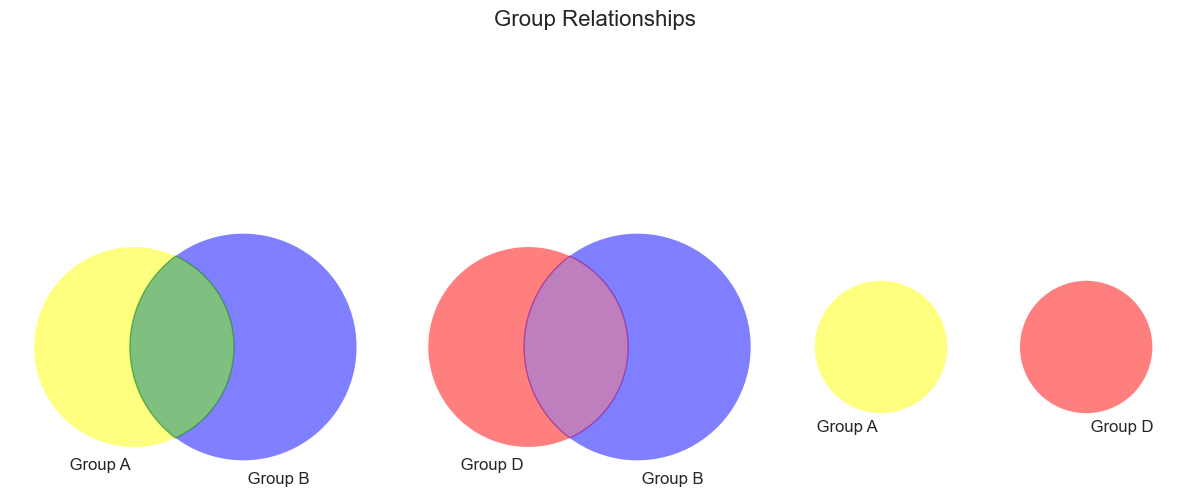

In [39]:
fig, ax = plt.subplots(1, 3, figsize=(12, 8))

v = venn.venn2(subsets=(4, 6, 3), set_labels=(' Group A ', ' Group B '), set_colors=('yellow', 'blue'), alpha=0.5, ax=ax[0])
v.get_label_by_id('10').set_text('')
v.get_label_by_id('01').set_text('')
v.get_label_by_id('11').set_text('')
v.get_patch_by_id('11').set_color('green')

w = venn.venn2(subsets=(4, 6, 3), set_labels=(' Group D ', ' Group B '), set_colors=('red', 'blue'), alpha=0.5, ax=ax[1])
w.get_label_by_id('10').set_text('')
w.get_label_by_id('01').set_text('')
w.get_label_by_id('11').set_text('')
w.get_patch_by_id('11').set_color('purple')

x = venn.venn2(subsets=(4, 4, 0), set_labels=(' Group A ', ' Group D '), set_colors=('yellow', 'red'), alpha=0.5, ax=ax[2])
x.get_label_by_id('10').set_text('')
x.get_label_by_id('01').set_text('')

fig.suptitle('Group Relationships', fontsize=16, y=0.9)
plt.tight_layout()
fig.savefig('group_relationships.png', dpi=300)
plt.show()

In [4]:
# one entry per group per day
numbers = [col for col in mccabe.columns if col not in ["ID", "date", "stat", "group"]]

mccabe_full = mccabe.groupby(["date", "group", "stat"])[numbers].sum().reset_index()

I built several functions to handle the disaggregation of the data. In addition to comparing and subtracting the subsets, I also added empty rows to the dataframes to make sure that the dataframes had the same number of rows. I will be aggregating the data later on, so this will not imapct the inteegrity of the data. It's also important to note that the disaggregation only breaks up the data into mutually exclusive categories, not into individual, user-level observations.

In [5]:
# add empty rows when subset has no activity (assume this is observed in the data)
def add_missing_level(df, set_name):
    if len(df["level"].unique()) < 3:
        missing = [l for l in ["ha", "ma", "la"] if l not in df["level"].unique()][0]

        empty = {}
        for col in df.columns:
            if col in ["grouping"]:
                empty[col] = set_name
            elif col in ["level"]:
                empty[col] = missing
            elif col == "stat":
                empty[col] = df["stat"].iloc[0]
            elif pd.api.types.is_numeric_dtype(df[col]):
                empty[col] = 0
            else:
                empty[col] = df[col].iloc[0]

        df = pd.concat([df, pd.DataFrame([empty])], ignore_index=True)

    return df


def preprocessing(df_raw, date):
    df = df_raw.loc[df_raw["date"] == date].reset_index(drop=True)

    ha, ma, la = [
        df.loc[(df["group"] == g) & (df["stat"] == "total")]
        for g in ["ha", "ma", "la"]
    ]

    su = df.loc[df["group"].str.contains(r"\_[hml]a")]

    groupings = (
        su["group"]
        .str.split("_", expand=True)
        .rename(columns={0: "grouping", 1: "level"})
    )

    sub = pd.concat(
        [su.drop(columns=["group"], errors="ignore"), groupings],
        axis=1,
    )

    groups = ["A", "D", "F", "nfns"]
    processed_groups = {}

    for g in groups:
        g_df = sub[sub["grouping"] == g].copy()
        out = []
        for stat in ["total", "avg"]:
            tmp = g_df[g_df["stat"] == stat]
            tmp = add_missing_level(tmp, g)
            tmp["date"] = date
            out.append(tmp)
        processed_groups[g] = out

    return ha, ma, la, processed_groups, sub, groups


def process_suspended(suspended):

    suspended_common = pd.DataFrame(
        {
            "stat": "total",
            "grouping": "suspended",
            "level": ["ha", "ma", "la"],
        }
    )
    suspended = suspended.reset_index().join(suspended_common, rsuffix="_common")
    return suspended


def pull_B(sub, processed_groups):
    numeric_cols = sub.select_dtypes(include="number").columns

    B_total = add_missing_level(
        sub[(sub["grouping"] == "B") & (sub["stat"] == "total")], "B"
    )
    B_avg = add_missing_level(
        sub[(sub["grouping"] == "B") & (sub["stat"] == "avg")], "B"
    )

    A_tot = processed_groups["A"][0].set_index("level")[numeric_cols]
    D_tot = processed_groups["D"][0].set_index("level")[numeric_cols]

    A_avg = processed_groups["A"][1].set_index("level")[numeric_cols]
    D_avg = processed_groups["D"][1].set_index("level")[numeric_cols]

    B_tot_vals = B_total.set_index("level")[numeric_cols]
    resid_tot = B_tot_vals - A_tot - D_tot

    resid_avg = (
        B_avg.set_index("level")[numeric_cols] * B_tot_vals
        - A_avg * A_tot
        - D_avg * D_tot
    ) / resid_tot.replace(0, np.nan)

    def finalize(df, stat):
        out = df.reset_index()
        out["grouping"] = "B"
        out["stat"] = stat
        return out

    B_total_out = finalize(resid_tot, "total")
    B_avg_out = finalize(resid_avg, "avg")

    return numeric_cols, pd.concat([B_total_out, B_avg_out], ignore_index=True)


def impute_NDU(B, ha, ma, la, processed_groups, groups):
    all_levels = (
        pd.concat([ha, ma, la])
        .rename(columns={"group": "level"})
        .set_index("level")
    )

    ndu = {}
    for stat in ["total", "avg"]:
        parts = []
        for g in groups:
            parts.append(processed_groups[g][0 if stat == "total" else 1])
        parts.append(B[B["stat"] == stat])

        tmp = (
            pd.concat(parts)
            .groupby("level")
            .sum(numeric_only=True)
        )
        tmp["stat"] = stat
        ndu[stat] = tmp

    return all_levels, ndu


def recombine(date, processed_groups, B, suspended):
    dfs_to_concat = []
    for group in processed_groups.values():
        for item in group:
            if isinstance(item, pd.DataFrame):
                dfs_to_concat.append(item)

    if not isinstance(B, pd.DataFrame):
        B = pd.DataFrame(B)

    if date < datetime(2021, 1, 12):
        suspended_p = process_suspended(suspended)
        dfs_to_concat.append(suspended_p)

    exclusive_groups = pd.concat(dfs_to_concat, ignore_index=True)

    return exclusive_groups


def aggregation_func(df_raw, date):
    ha, ma, la, processed_groups, sub, groups = preprocessing(df_raw, date)

    numeric_columns, B = pull_B(sub, processed_groups)

    all_levels, ndu = impute_NDU(B, ha, ma, la, processed_groups, groups)

    suspended_total = all_levels[numeric_columns] - ndu["total"][numeric_columns]

    suspended_avg = (
        all_levels[numeric_columns] * all_levels[numeric_columns]
        - ndu["avg"][numeric_columns] * ndu["total"][numeric_columns]
    ) / suspended_total.replace(0, np.nan)

    suspended = pd.concat([
        suspended_total.assign(stat="total"),
        suspended_avg.assign(stat="avg")
    ])
    suspended["grouping"] = "suspended"
    suspended["date"] = date

    final = recombine(date, processed_groups, B, suspended)
    return final

In [6]:
mut_exclusive_groups = []

for day in mccabe_full["date"].unique():
    mut_exclusive_groups.append(aggregation_func(mccabe_full, day))

total = pd.concat(mut_exclusive_groups).reset_index(drop=True)
# Create a new column 'subsets' by combining 'grouping' and 'level'
total.loc[:, "subsets"] = total["grouping"] + "_" + total["level"]
total = total.drop(columns=["grouping_common", "stat_common", "level_common"]).reset_index(
    drop=True
)


In [16]:
# total.to_csv("total.csv", index=False)
total = pd.read_csv("total.csv")

In [17]:
total['date'] = pd.to_datetime(total['date'].apply(lambda x: datetime.strptime(x, "%Y-%m-%d").date()))

In [18]:
total['grouping'].unique()

array(['A', 'D', 'F', 'nfns', 'suspended'], dtype=object)

Data collection was an inexhaustive process, so it's important to verify the sudden changes in each groups' behavior. Some changes can be explained by parallel changes in other groups; the number of low activity users sharply declines around July 2020, but at the same time the number of high activity users sharply increases. 

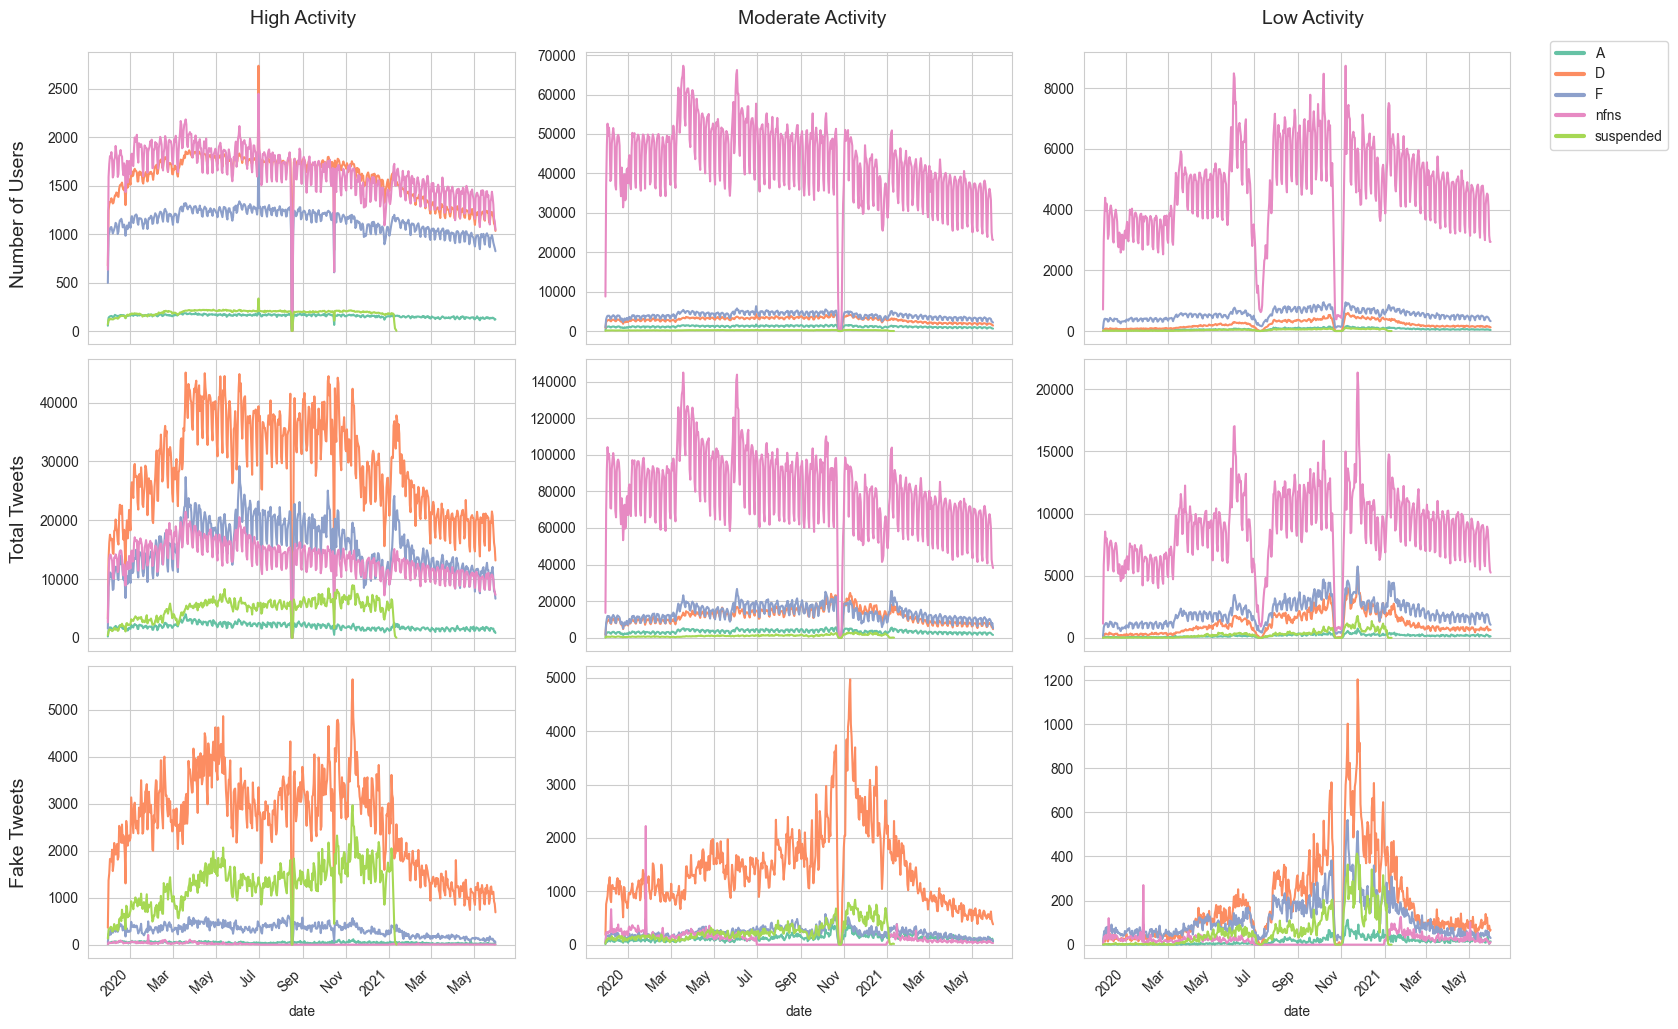

In [133]:
fig, ax = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
for L in total['subset_activity'].unique():
    if L == 'ha':
        i = 0
        title = 'High'
    elif L == 'ma':
        i = 1
        title = 'Moderate'
    else:
        i = 2
        title = 'Low'
    d = total.loc[total['subset_activity'] == L]
    sns.lineplot(d, x='date', y='nusers', hue='subset_group', palette='Set2', ax=ax[0, i])
    sns.lineplot(d, x='date', y='n', hue='subset_group', palette='Set2', ax=ax[1, i])
    sns.lineplot(d, x='date', y='fake_merged', hue='subset_group', palette='Set2', ax=ax[2, i])

fig.text(-0.01, 0.75, 'Number of Users', rotation=90, fontsize=14)
fig.text(-0.01, 0.475, 'Total Tweets', rotation=90, fontsize=14)
fig.text(-0.01, 0.15, 'Fake Tweets', rotation=90, fontsize=14)

fig.text(0.15, 1.01, 'High Activity', fontsize=14)
fig.text(0.475, 1.01, 'Moderate Activity', fontsize=14)
fig.text(0.825, 1.01, 'Low Activity', fontsize=14)

handles, labels = ax[0, 0].get_legend_handles_labels()
for h in handles:
    h.set_linewidth(3)
fig.legend(handles, labels, loc='upper right', ncol=1, bbox_to_anchor=(1.1, 1))

for a in ax.flatten():
    a.xaxis.set_major_locator(mdates.AutoDateLocator())
    a.xaxis.set_major_formatter(mdates.ConciseDateFormatter(a.xaxis.get_major_locator()))
    plt.setp(a.xaxis.get_majorticklabels(), rotation=45, ha='right')
    a.get_legend().remove()
    a.yaxis.set_label_text('')

plt.tight_layout()
plt.show()

In [23]:
features = ['fake_merged_initiation', 'fake_merged_rt', 'not_fake_conservative', 'not_fake_liberal', 'not_fake_shopping', 'not_fake_sports', 'n', 'nusers', 'grouping', 'level', 'date']

df = total.copy().loc[:, features].pivot_table(index='date', columns=['grouping', 'level'], values=['fake_merged_initiation', 'fake_merged_rt', 'not_fake_conservative', 'not_fake_liberal', 'not_fake_shopping', 'not_fake_sports', 'n', 'nusers'], fill_value=0).asfreq('D').fillna(0)
df.columns = ['_'.join(col).strip() for col in df.columns.values]

treatment_start = '2021-01-07'
treatment_end = '2021-01-12'

pretreatment_df = df.loc[:treatment_start]
posttreatment_df = df.loc[treatment_end:]

In [24]:
from adtk.detector import MinClusterDetector
from adtk.pipe import Pipeline
from adtk.data import validate_series
from adtk.transformer import PcaProjection
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

min_cluster_detector = MinClusterDetector(KMeans(n_clusters=4))
steps = [
    ("projection", PcaProjection(k=2)),
    ("detector", min_cluster_detector)
]
pipeline = Pipeline(steps)
pre_treated = validate_series(pretreatment_df)
pre_anomalies = pipeline.fit_detect(pre_treated).reset_index().rename(columns={0: "anomaly"})

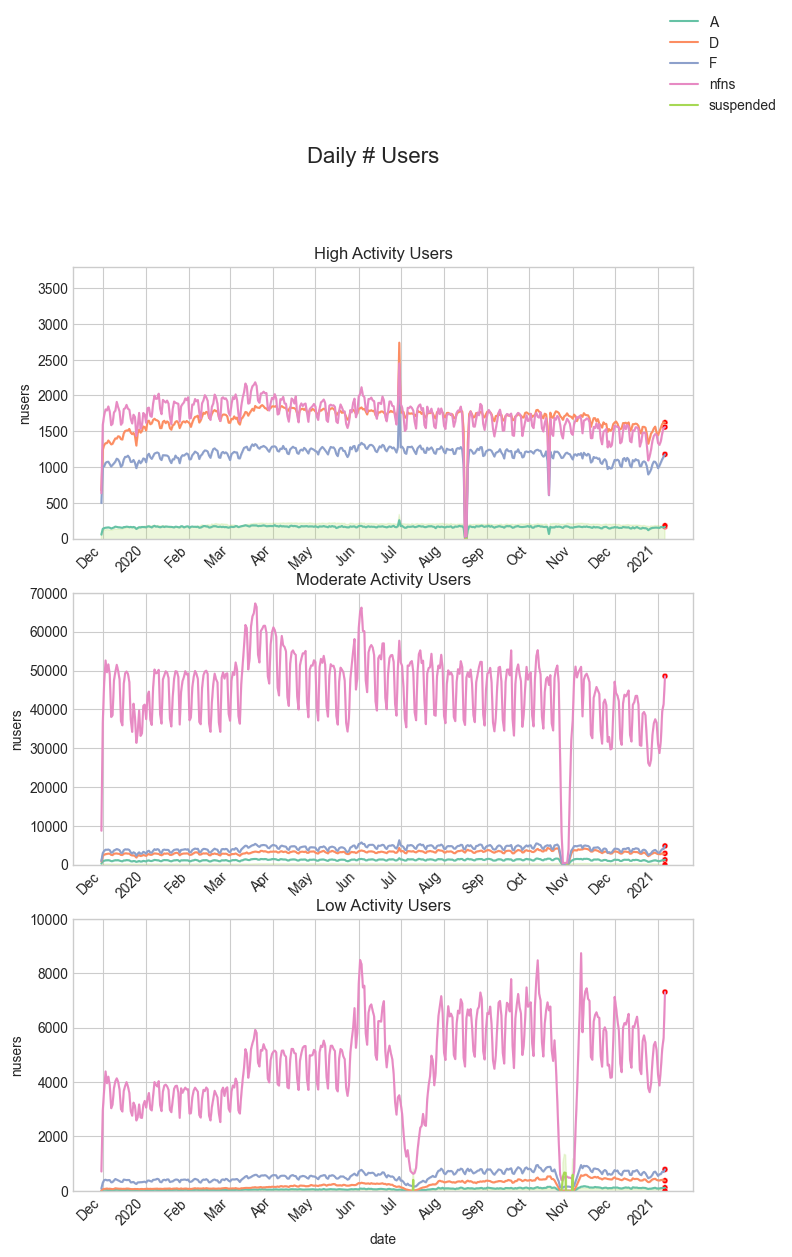

In [33]:
pre_outlier_data = total.loc[total['date'] < '2021-01-07'].join(pre_anomalies.set_index('date'), on='date')
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(3, 1, figsize=(8, 12))

for L in ['ha', 'ma', 'la']:
    if L == 'ha':
        i = 0
        title = 'High'
    elif L == 'ma':
        i = 1
        title = 'Moderate'
    else:
        i = 2
        title = 'Low'
    name = f"{title} Activity Users"
    sns.lineplot(x='date', y='nusers', data=pre_outlier_data.loc[pre_outlier_data['level'] == L], ax=ax[i], hue='grouping', palette='Set2')
    sns.scatterplot(x='date', y='nusers', data=pre_outlier_data.loc[(pre_outlier_data['level'] == L) & (pre_outlier_data['anomaly'] == True)], ax=ax[i], color='red', legend=False, size=800)
    ax[i].set_title(name)
fig.suptitle('Daily # Users', fontsize=16)
ax[0].set_ylim(0, 3800)
ax[1].set_ylim(0, 70000)
ax[2].set_ylim(0, 10000)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=1, bbox_to_anchor=(1.02, 1.1))
for i, a in enumerate(ax):
    a.xaxis.set_major_locator(mdates.MonthLocator())
    a.xaxis.set_major_formatter(mdates.ConciseDateFormatter(a.xaxis.get_major_locator()))
    plt.setp(a.xaxis.get_majorticklabels(), rotation=45, ha='right')
    a.get_legend().remove()
    if i != 2:
        a.xaxis.set_label_text('')

The main outliers seem to be the earliest observations, as well as the general downward trend in November 2020.

## Sources
McCabe, S.D., Ferrari, D., Green, J. et al. Post-January 6th deplatforming reduced the reach of misinformation on Twitter. Nature 630, 132–140 (2024). https://doi.org/10.1038/s41586-024-07524-8